<a href="https://colab.research.google.com/github/robertmadril15/CS4410/blob/main/Homework6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


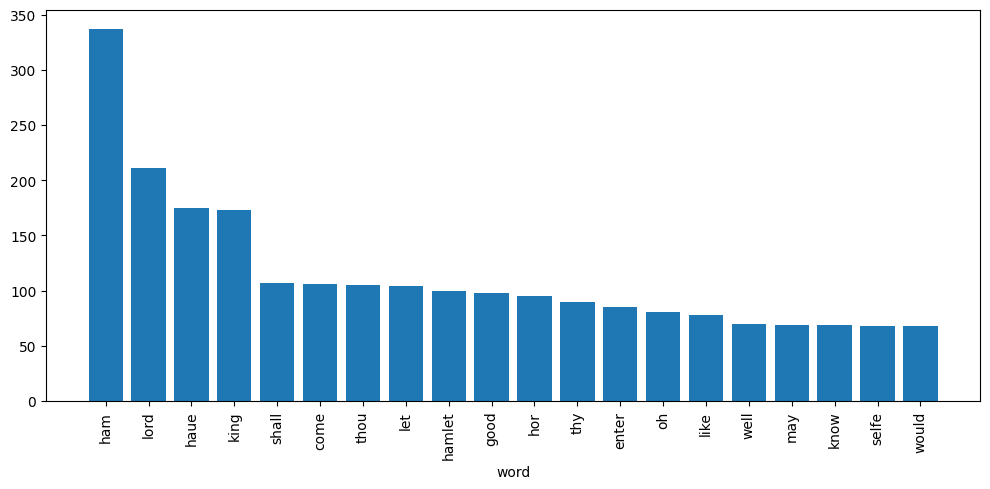

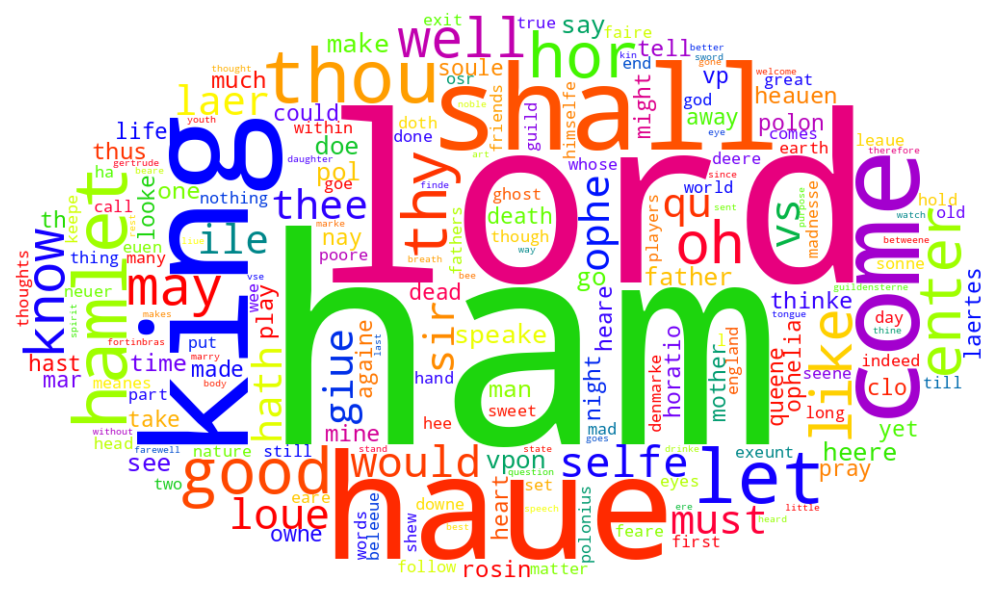

In [8]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

import requests
from textblob import TextBlob
from nltk.corpus import stopwords
import string
from collections import Counter

import matplotlib.pyplot as plt
from wordcloud import WordCloud

targetUrl = 'https://www.gutenberg.org/files/2265/2265-0.txt'
response = requests.get(targetUrl)
data = response.text

blob = TextBlob(data)

stopWords = set(stopwords.words('english'))

words = [
    w.lower() for w in blob.words
    if w.isalpha() and w.lower() not in stopWords
]

wordFreq = Counter(words)
topTwenty = wordFreq.most_common(20)

topWords = [w for w, c in topTwenty]
topCounts = [c for w, c in topTwenty]

plt.figure(figsize=(10, 5))
plt.bar(topWords, topCounts)
plt.xticks(rotation=90)
plt.xlabel("word")
plt.tight_layout()
plt.show()

import imageio
imageFile = "https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png"
maskImage =imageio.v3.imread(imageFile)

wordcloud = WordCloud(
    colormap='prism',
    mask=maskImage,
    background_color='white'
).generate_from_frequencies(wordFreq)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()